# RDD
## Simulation

In [1]:
pip install rdrobust

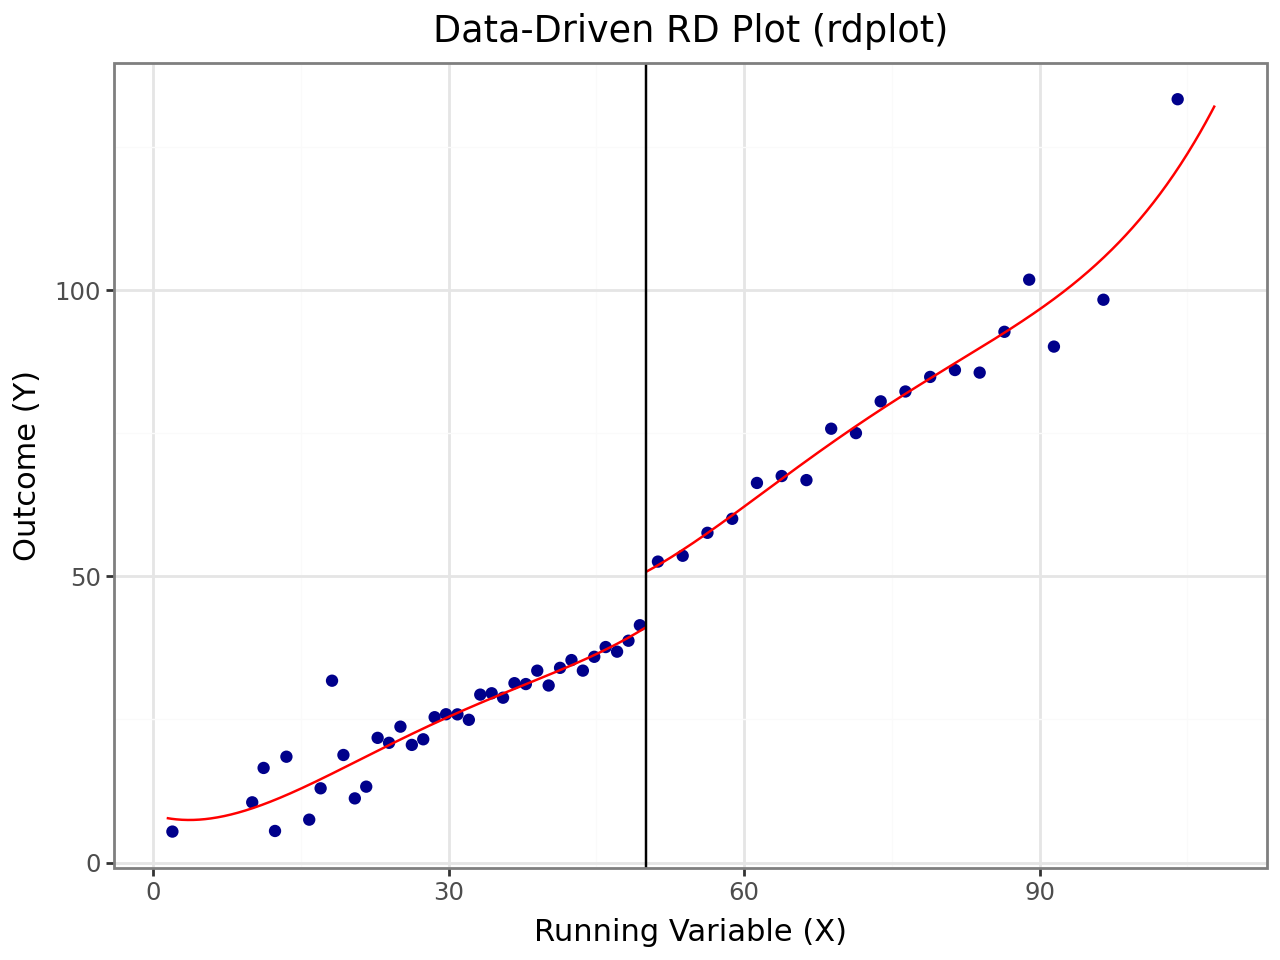

<Figure size 1000x600 with 0 Axes>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdrobust import rdrobust, rdplot


# ==========================================
# 1. SIMULATION (Data Generation)
# ==========================================
np.random.seed(42)
n_obs = 1000
cutoff = 50

# Running variable and Treatment
X = np.random.normal(loc=50, scale=15, size=n_obs)
X_centered = X - cutoff
treatment = (X >= cutoff).astype(int)

# True parameters
true_tau = 10.0
beta_0 = 40.0
beta_1 = 0.8
beta_2 = 0.4

# Generate outcome with noise
epsilon = np.random.normal(loc=0, scale=8, size=n_obs)
Y = beta_0 + (beta_1 * X_centered) + (true_tau * treatment) + (beta_2 * X_centered * treatment) + epsilon

df = pd.DataFrame({'X': X, 'X_centered': X_centered, 'Treatment': treatment, 'Y': Y})


plt.figure(figsize=(10, 6))

# Generate the RD plot
# Note: rdplot returns a dictionary of matplotlib objects, we can customize the plot via these objects if needed.
rdplot_result = rdplot(y=df['Y'], x=df['X'], c=cutoff,
                       title="Data-Driven RD Plot (rdplot)",
                       x_label="Running Variable (X)",
                       y_label="Outcome (Y)")

plt.show()

In [3]:
# ==========================================
# 2. ESTIMATION & INFERENCE (rdrobust)
# ==========================================
print("="*75)
print(" rdrobust: Optimal Bandwidth & Robust Bias-Corrected Inference")
print("="*75)

# Run rdrobust
# y: outcome, x: running variable, c: cutoff
# By default, it uses a triangular kernel, local linear regression (p=1),
# and calculates the MSE-optimal bandwidth.
rd_result = rdrobust(y=df['Y'], x=df['X'], c=cutoff)

# Print the comprehensive summary output
print(rd_result)

# Extract specific values for our own custom plotting later
# 'h_l' and 'h_r' are the optimal bandwidths for the left and right sides
h_left = rd_result.bws.iloc[0, 0]
h_right = rd_result.bws.iloc[0, 1]
estimated_tau = rd_result.coef.iloc[0]

print("\n" + "-"*75)
print(f"Extracted Optimal Bandwidth (Left):  {h_left:.4f}")
print(f"Extracted Optimal Bandwidth (Right): {h_right:.4f}")
print(f"Extracted Treatment Effect:          {estimated_tau[0]:.4f}")
print("-"*75)

# ==========================================
# 3. VISUALIZATION (rdplot)
# ==========================================
# The rdrobust package includes rdplot for data-driven RD plots.
# It automatically selects the optimal number of bins for visualization.


 rdrobust: Optimal Bandwidth & Robust Bias-Corrected Inference
Call: rdrobust
Number of Observations:                  1000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           490        510
Number of Unique Obs.            490        510
Number of Effective Obs.         236        254
Bandwidth Estimation           9.515      9.515
Bandwidth Bias                14.626     14.626
rho (h/b)                      0.651      0.651

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       9.535    1.507    6.327   2.505e-10    [6.581, 12.489]
Robust                 -        -    5.2

/tmp/ipykernel_2827/2686689796.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [4]:
# ==========================================
# 3. MANUAL REPLICATION USING WLS (smf.wls)
# ==========================================
import statsmodels.formula.api as smf
def asymmetric_triangular_kernel(x_centered, h_l, h_r):
    """Calculates Triangular Kernel weights using asymmetric bandwidths."""
    weights = np.zeros_like(x_centered, dtype=float)

    # Left side (Control: x_centered < 0)
    left_mask = (x_centered < 0) & (x_centered >= -h_l)
    weights[left_mask] = 1 - np.abs(x_centered[left_mask] / h_l)

    # Right side (Treatment: x_centered >= 0)
    right_mask = (x_centered >= 0) & (x_centered <= h_r)
    weights[right_mask] = 1 - np.abs(x_centered[right_mask] / h_r)

    return weights

# Apply the asymmetric weights to our dataframe
df['weight'] = asymmetric_triangular_kernel(df['X_centered'], h_left, h_right)

# Keep only observations within the bandwidths (weight > 0)
df_local = df[df['weight'] > 0]

# Run Weighted Least Squares using the exact weights
# We use HC3 standard errors, though standard errors will differ slightly from
# rdrobust's conventional SEs due to degrees of freedom adjustments in the package.
model_wls = smf.wls('Y ~ X_centered * Treatment',
                    data=df_local,
                    weights=df_local['weight']).fit(cov_type='HC3')

wls_point_estimate = model_wls.params['Treatment']

print("\n" + "="*65)
print(" 2. Manual WLS Replication Output")
print("="*65)
print(f"Manual WLS Point Estimate:     {wls_point_estimate:.6f}")
print(f"Difference (rdrobust - WLS):   {abs(estimated_tau[0] - wls_point_estimate):.2e}")
print("="*65)

print(model_wls.summary() )


 2. Manual WLS Replication Output
Manual WLS Point Estimate:     9.534823
Difference (rdrobust - WLS):   4.80e-14
                            WLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.519
Model:                            WLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     190.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.28e-81
Time:                        10:14:53   Log-Likelihood:                -1784.3
No. Observations:                 490   AIC:                             3577.
Df Residuals:                     486   BIC:                             3593.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------

/tmp/ipykernel_2827/1059719763.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


##  Ferrer, Geyn & Thompson (2024)

In [5]:
import io
import tarfile
import zipfile
from pathlib import Path

import pandas as pd
import requests
from rdrobust import rdrobust

# =========================================================
# Ferrer, Geyn & Thompson (APSR)
# "How Partisan Is Local Election Administration?"
# Harvard Dataverse PID
# =========================================================
PID = "doi:10.7910/DVN/SHYPDU"
BASE = "https://dataverse.harvard.edu"
WORKDIR = Path("ferrer_geyn_thompson")
WORKDIR.mkdir(exist_ok=True)

BUNDLE_PATH = WORKDIR / "dataset_bundle.zip"
EXTRACT_DIR = WORKDIR / "extracted"
EXTRACT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def download_file(url, out_path):
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

def extract_any(path, out_dir):
    suffixes = "".join(path.suffixes).lower()

    if suffixes.endswith(".zip"):
        with zipfile.ZipFile(path, "r") as zf:
            zf.extractall(out_dir)
        return

    if suffixes.endswith(".tar.gz") or suffixes.endswith(".tgz") or suffixes.endswith(".tar"):
        with tarfile.open(path, "r:*") as tf:
            tf.extractall(out_dir)
        return

    raise ValueError(f"Unsupported archive format: {path}")

def pick_col(df, candidates):
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}

    # exact match first
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]

    # substring match next
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c

    raise KeyError(f"Could not find any of {candidates}\nAvailable columns:\n{cols}")

def load_table(path):
    suf = path.suffix.lower()
    if suf == ".dta":
        return pd.read_stata(path)
    if suf == ".csv":
        return pd.read_csv(path)
    if suf in [".txt", ".tsv"]:
        try:
            return pd.read_csv(path, sep="\t")
        except Exception:
            return pd.read_csv(path)
    raise ValueError(f"Unsupported tabular file: {path}")

# ---------------------------------------------------------
# 1. Download full dataset bundle from Dataverse
# ---------------------------------------------------------
bundle_url = f"{BASE}/api/access/dataset/:persistentId/?persistentId={PID}&format=original"
print("Downloading full dataset bundle...")
download_file(bundle_url, BUNDLE_PATH)
print("Saved bundle to:", BUNDLE_PATH)

# ---------------------------------------------------------
# 2. Extract bundle
# ---------------------------------------------------------
print("Extracting bundle...")
extract_any(BUNDLE_PATH, EXTRACT_DIR)




Saved bundle to: ferrer_geyn_thompson/dataset_bundle.zip
Extracting bundle...


In [6]:
import pandas as pd
from rdrobust import rdrobust

DATA_PATH = "ferrer_geyn_thompson/extracted/How_Partisan_Is_Local_Election_Admin_Replication/analysis_data/rd_reg_turnout_analysis_data.dta"

# Load data
df = pd.read_stata(DATA_PATH, convert_categoricals=False)
#print(df.columns.tolist())

# Variables
x_col = "rv"            # running variable
d_col = "treat"         # treatment: Democratic election official wins
y_col = "turnout_pres"  # outcome

# Clean numeric data
x = pd.to_numeric(df[x_col], errors="coerce")
d = pd.to_numeric(df[d_col], errors="coerce")
y = pd.to_numeric(df[y_col], errors="coerce")

mask = x.notna() & d.notna() & y.notna()
x = x[mask].to_numpy()
d = d[mask].to_numpy()
y = y[mask].to_numpy()

print("N =", len(x))
print("Running variable:", x_col)
print("Treatment:", d_col)
print("Outcome:", y_col)



# Reduced form / sharp RD for turnout
res = rdrobust(y=y, x=x, c=0.0)
print("\nRDD result for turnout_pres:")
print(res)

N = 937
Running variable: rv
Treatment: treat
Outcome: turnout_pres

RDD result for turnout_pres:
Call: rdrobust
Number of Observations:                   937
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           516        421
Number of Unique Obs.            504        402
Number of Effective Obs.         201        212
Bandwidth Estimation           0.085      0.085
Bandwidth Bias                 0.123      0.123
rho (h/b)                      0.695      0.695

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.015    0.021    0.734   4.627e-01    [-0.025, 0.056]
Robus

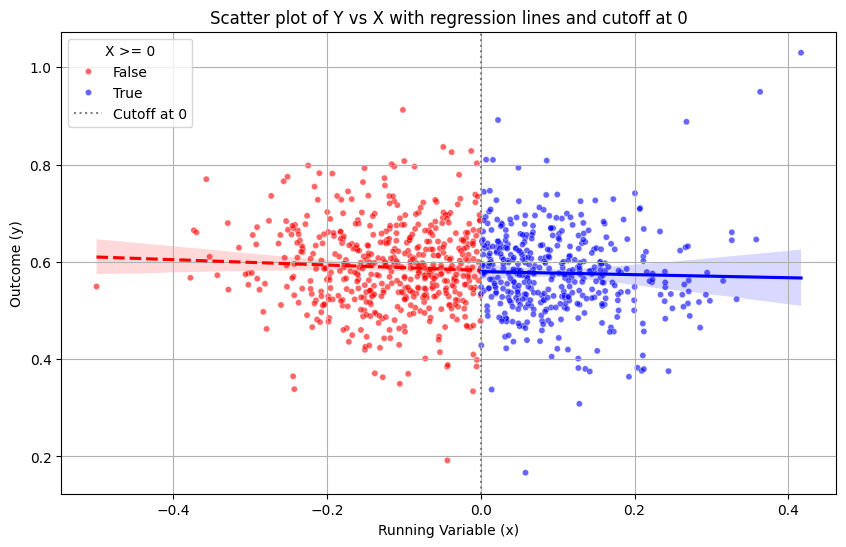

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
data = pd.DataFrame({'x': x, 'y': y})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='x', y='y', hue=data['x'] >= 0, palette=['red', 'blue'], alpha=0.6, s=20)

# Plot regression line for x < 0
sns.regplot(data=data[data['x'] < 0], x='x', y='y', scatter=False, color='red', line_kws={'linestyle':'--'})

# Plot regression line for x >= 0
sns.regplot(data=data[data['x'] >= 0], x='x', y='y', scatter=False, color='blue', line_kws={'linestyle':'-'})

plt.axvline(x=0, color='gray', linestyle=':', label='Cutoff at 0')
plt.title('Scatter plot of Y vs X with regression lines and cutoff at 0')
plt.xlabel('Running Variable (x)')
plt.ylabel('Outcome (y)')
plt.legend(title='X >= 0')
plt.grid(True)
plt.show()